# Modelos de Conteo: Poisson vs Negative Binomial
# Series de tiempo de casos de sarampion

El objetivo de este analisis es comparar modelos de conteo que manejan muchos ceros e incorporan retardos y covariables, respetando la estructura temporal.

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.max_columns", None)
np.seterr(divide="ignore", invalid="ignore")

{'divide': 'ignore', 'over': 'warn', 'under': 'ignore', 'invalid': 'ignore'}

In [5]:
data_path = Path("../..") / "data" / "processed" / "dataset_sarampion_features_engineered.csv"
df = pd.read_csv(data_path)

df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

target = "casos_sarampion"
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
print("Periodo:", df["fecha"].min().date(), "-", df["fecha"].max().date())

zero_rate = (df[target] == 0).mean()
print(f"Proporcion de ceros en {target}: {zero_rate:.2%}")
display(df.head())

Filas: 168 | Columnas: 26
Periodo: 2010-01-01 - 2023-12-01
Proporcion de ceros en casos_sarampion: 89.88%


,fecha,anio,mes,casos_sarampion,tasa_casos_por_millon_dosis,casos_sarampion_log,casos_ytd_log,casos_rolling_mean_3m_log,casos_rolling_mean_6m_log,dosis_lag_14m_log,dosis_lag_13m_log,total_dosis_log,dosis_rolling_mean_3m_log,dosis_rolling_std_3m_log,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,FA_1,FA_2,FA_3,FA_4,FA_5
0,2010-01-01,2010,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.417548,0.000000,0.000000,-0.716212,-0.306848,-0.091227,-0.270210,-0.368441,0.050798,0.078258,-0.432794,0.145077,-0.125159,0.167979,-0.112603
1,2010-02-01,2010,2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.392925,0.000000,0.000000,-0.717051,-0.299481,-0.095048,-0.271172,-0.351363,0.047698,0.073574,-0.432810,0.145104,-0.124431,0.168743,-0.108579
2,2010-03-01,2010,3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.099572,0.000000,0.000000,-0.733845,-0.152135,-0.171470,-0.290416,-0.009779,-0.014305,-0.020122,-0.433144,0.145662,-0.109877,0.184018,-0.028090
3,2010-04-01,2010,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.101184,-0.465865,-0.507478,-0.701289,-0.832234,-0.071659,-0.300450,0.133035,-0.107357,0.078814,-0.429755,0.086855,-0.598898,0.158234,0.145777
4,2010-05-01,2010,5,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.479683,-0.340831,-0.632944,-0.690697,-0.972147,-0.029940,-0.286307,-0.084649,-0.097605,0.277499,-0.430911,0.077019,-0.622027,0.165348,0.264341


In [6]:
# Retardos del target para capturar dependencia temporal
df["casos_lag_1m"] = df[target].shift(1)
df["casos_lag_12m"] = df[target].shift(12)

# Split temporal: ultimos 12 meses como prueba
cutoff = df["fecha"].max() - pd.DateOffset(months=12)
train_df = df[df["fecha"] <= cutoff].copy()
test_df = df[df["fecha"] > cutoff].copy()

print("Train:", train_df.shape[0], "| Test:", test_df.shape[0])
print("Train rango:", train_df["fecha"].min().date(), "-", train_df["fecha"].max().date())
print("Test rango:", test_df["fecha"].min().date(), "-", test_df["fecha"].max().date())

Train: 156 | Test: 12
Train rango: 2010-01-01 - 2022-12-01
Test rango: 2023-01-01 - 2023-12-01


In [7]:
# Seleccion de covariables: todas las numericas excepto identificadores y target
exclude_cols = {"anio", "mes", "fecha", target}
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c not in exclude_cols]

# Asegurar que los lags del target esten incluidos
for lag_col in ["casos_lag_1m", "casos_lag_12m"]:
    if lag_col not in feature_cols:
        feature_cols.append(lag_col)

# Armado de matrices de diseno (sin fuga por NA de lags)
train_x = train_df[feature_cols].copy()
train_y = train_df[target].copy()
test_x = test_df[feature_cols].copy()
test_y = test_df[target].copy()

train_x = train_x.replace([np.inf, -np.inf], np.nan)
test_x = test_x.replace([np.inf, -np.inf], np.nan)

train_mask = train_x.notna().all(axis=1)
test_mask = test_x.notna().all(axis=1)

train_x = train_x[train_mask]
train_y = train_y[train_mask]
test_x = test_x[test_mask]
test_y = test_y[test_mask]

# Intercepto explicito
train_x = sm.add_constant(train_x, has_constant="add")
test_x = sm.add_constant(test_x, has_constant="add")

print("Features usadas:", len(train_x.columns))
display(train_x.head())

Features usadas: 25


,const,tasa_casos_por_millon_dosis,casos_sarampion_log,casos_ytd_log,casos_rolling_mean_3m_log,casos_rolling_mean_6m_log,dosis_lag_14m_log,dosis_lag_13m_log,total_dosis_log,dosis_rolling_mean_3m_log,dosis_rolling_std_3m_log,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,FA_1,FA_2,FA_3,FA_4,FA_5,casos_lag_1m,casos_lag_12m
12,1.0,0.0,0.0,0.0,1.992430,3.083438,0.000000,0.000000,0.357782,1.026202,-1.493049,1.853194,-0.608931,-0.948330,1.579293,0.984984,-0.972250,2.418997,1.092073,-2.378851,-0.030376,-0.630891,2.828946,0.0,0.0
13,1.0,0.0,0.0,0.0,0.847298,2.120264,0.000000,-0.411979,0.821436,0.804205,0.025009,0.786429,0.491884,-0.942295,0.660961,0.486803,-0.605158,0.843601,0.548331,-1.417421,0.550674,-0.221042,1.205100,0.0,0.0
14,1.0,0.0,0.0,0.0,0.000000,1.427116,-0.426074,-0.383186,1.169468,0.711756,-0.119789,0.037433,0.386952,-0.970331,-0.077749,0.788056,-0.331708,0.506583,0.154995,-0.848152,0.319090,0.320437,1.174011,0.0,0.0
15,1.0,0.0,0.0,0.0,0.000000,1.427116,-0.396532,0.192731,0.587887,0.822495,0.149783,-0.036742,0.489980,-0.698051,0.141551,0.356559,0.064183,0.585742,0.150979,-0.811496,0.495711,0.205612,0.904849,0.0,0.0
16,1.0,0.0,0.0,0.0,0.000000,0.510826,0.194344,-0.042029,-0.362422,0.899895,-0.049690,-0.512837,0.152726,-0.276571,-0.024007,-0.376122,-0.156326,0.595794,-0.233704,-0.185965,0.310172,0.083366,0.638615,0.0,0.0


## Modelos de conteo: Poisson y Negative Binomial (antes de ajustar)

Se quiere predecir  un numero de casos por mes. Ese numero es un conteo (0, 1, 2, ...) y no una variable continua. Por eso usamos modelos de conteo.

- **Poisson**: es el modelo base para conteos. Supone que la variabilidad es similar al promedio ($E[Y]=Var(Y)$). Funciona bien cuando los datos no tienen demasiados ceros extra ni picos extremos.
- **Negative Binomial**: es una version mas flexible. Mantiene el enlace log, pero permite mas variabilidad que el promedio ($Var(Y)=\mu+\alpha\mu^2$). En series con brotes y muchos ceros, suele ajustarse mejor.

En esta comparativa aplicamos ambos para ver si el supuesto del Poisson es razonable o si la sobre-dispersion justifica Negative Binomial.

In [8]:
# Ajuste Poisson
poisson_model = sm.GLM(train_y, train_x, family=sm.families.Poisson()).fit()

# Ajuste Negative Binomial (busqueda simple de alpha por AIC)
alpha_grid = [0.1, 0.3, 0.5, 1.0, 2.0]
nb_models = []
for a in alpha_grid:
    nb = sm.GLM(train_y, train_x, family=sm.families.NegativeBinomial(alpha=a)).fit()
    nb_models.append((a, nb.aic, nb))

best_alpha, best_aic, nb_model = sorted(nb_models, key=lambda x: x[1])[0]
print(f"Mejor alpha NB por AIC: {best_alpha} | AIC: {best_aic:.2f}")

# Sobre-dispersion en Poisson (pearson chi2 / df_resid)
poisson_dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"Dispersion Poisson: {poisson_dispersion:.2f}")

print("\nPoisson AIC:", poisson_model.aic)
print("NegBin AIC:", nb_model.aic)

Mejor alpha NB por AIC: 0.1 | AIC: 99.92
Dispersion Poisson: 0.18

Poisson AIC: 94.15564672102029
NegBin AIC: 99.92098749248782


In [9]:
def poisson_deviance(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_pred = np.clip(y_pred, 1e-9, None)
    term = np.where(y_true == 0, -y_pred, y_true * np.log(y_true / y_pred) - (y_true - y_pred))
    return 2 * np.mean(term)

def eval_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    dev = poisson_deviance(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "Poisson_Deviance": dev}

# Predicciones en test
pred_pois = poisson_model.predict(test_x)
pred_nb = nb_model.predict(test_x)

metrics_pois = eval_metrics(test_y, pred_pois)
metrics_nb = eval_metrics(test_y, pred_nb)

print("Poisson:", metrics_pois)
print("NegBin:", metrics_nb)

# Proporcion de ceros: real vs. predicha
zero_rate_test = (test_y == 0).mean()
p0_pois = np.mean(np.exp(-pred_pois))
p0_nb = np.mean((1 / (1 + best_alpha * pred_nb)) ** (1 / best_alpha))

print(f"Ceros reales (test): {zero_rate_test:.2%}")
print(f"P(Y=0) Poisson promedio: {p0_pois:.2%}")
print(f"P(Y=0) NegBin promedio: {p0_nb:.2%}")

Poisson: {'MAE': 0.03772044668792294, 'RMSE': 0.04117778049671312, 'Poisson_Deviance': -0.07544089337584588}
NegBin: {'MAE': 0.025791929312948585, 'RMSE': 0.032293909088319, 'Poisson_Deviance': -0.05158385862589717}
Ceros reales (test): 100.00%
P(Y=0) Poisson promedio: 96.31%
P(Y=0) NegBin promedio: 97.48%


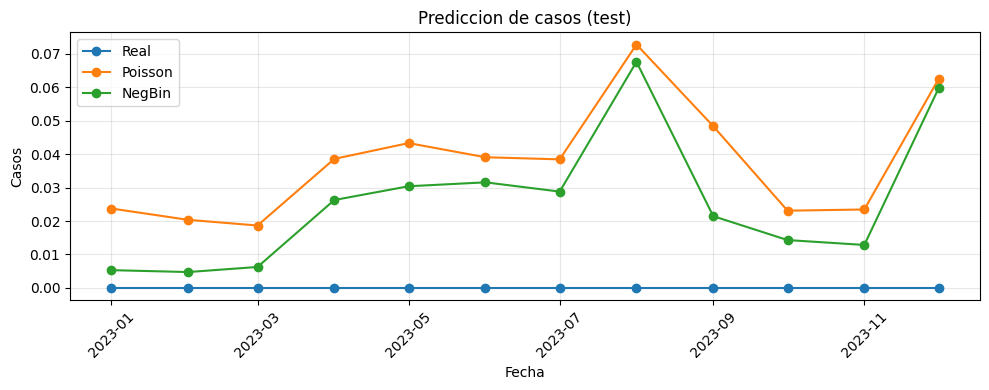

In [10]:
# Comparativo visual
plt.figure(figsize=(10, 4))
plt.plot(test_df.loc[test_y.index, "fecha"], test_y, label="Real", marker="o")
plt.plot(test_df.loc[test_y.index, "fecha"], pred_pois, label="Poisson", marker="o")
plt.plot(test_df.loc[test_y.index, "fecha"], pred_nb, label="NegBin", marker="o")
plt.title("Prediccion de casos (test)")
plt.xlabel("Fecha")
plt.ylabel("Casos")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

## Conclusiones

Se muestran resultados un poco alejados de la realidad. De hecho, Poisson presenta un comportamiento bastante preciso para lo que corresponde a su naturaleza; sin embargo, este modelo tiende a comportarse peor cuando existen muchos ceros(89%), que es precisamente el caso de nuestro dataset.

Por su parte, Negative Binomial logra aproximarse más al comportamiento real, aunque resulta interesante observar que mantiene una trayectoria similar a la de Poisson. Ambos modelos presentan cierto sesgo ya que los casos de sarampión no son suficientes por lo menos con el dataset actual y se vuelve dificil realizar una predicción eficaz. En la mayoría de los registros no se presentan casos de sarampión, lo que limita la capacidad predictiva.

Es importante mencionar que existe la posibilidad de que el dataset no sea adecuado, ya que a inicios de 2025 el boletín informativo de enfermedades como el sarampión comenzó a ser publicado por la Dirección General de Epidemiología. Esto puede contrastarse al observar que en los últimos años el boletín epidemiológico no menciona casos de sarampión.

En conclusión, entre estos dos modelos se elegiría Negative Binomial; sin embargo, con el dataset actual no se obtiene un resultado verdaderamente certero ni preciso.


Link de la publicación de datos de sarampion actuales (2025-2026): https://www.gob.mx/salud/acciones-y-programas/boletines-informativos-de-la-situacion-epidemiologica-de-las-enfermedades-prevenibles-por-vacunacion
